# Cognifyz Technologies: Machine Learning Development Internship Submission
**Author:** Suman Kumar Rana  
**Project:** Machine Learning Restaurant Modeling & Analytics on the Zomato Dataset
---
This Jupyter Notebook implements all tasks for the Cognifyz Machine Learning Development Internship:
- **Level 1 — Task 1:** Predictive Modeling (Aggregate Rating prediction)
- **Level 1 — Task 2:** Restaurant Recommendation System (Content-based filtering)
- **Level 2 — Task 1:** Cuisine Classification (Predicting primary cuisine)
- **Level 2 — Task 2:** Geographic Analysis (Mapping & K-Means clustering)
- **Level 3 — Task 1:** Sentiment Analysis (NLP classification on reviews text)
- **Level 3 — Task 2:** Feature Engineering & Model Improvement


## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Style plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('/Users/sumankumarrana/Public/Dataset.csv')
print(f"Dataset Loaded. Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(2)

Dataset Loaded. Rows: 9551, Columns: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


## 2. Level 1 — Task 1: Predictive Modeling (Regression)
Build and compare regression models (Linear Regression, Decision Tree, and Random Forest) to predict the `Aggregate rating` of restaurants based on features like cost, online delivery, table booking, price range, and votes.


               Model       MSE      RMSE  R-squared
0  Linear Regression  1.644970  1.282564   0.277288
1      Decision Tree  0.185067  0.430194   0.918692
2      Random Forest  0.095210  0.308560   0.958170


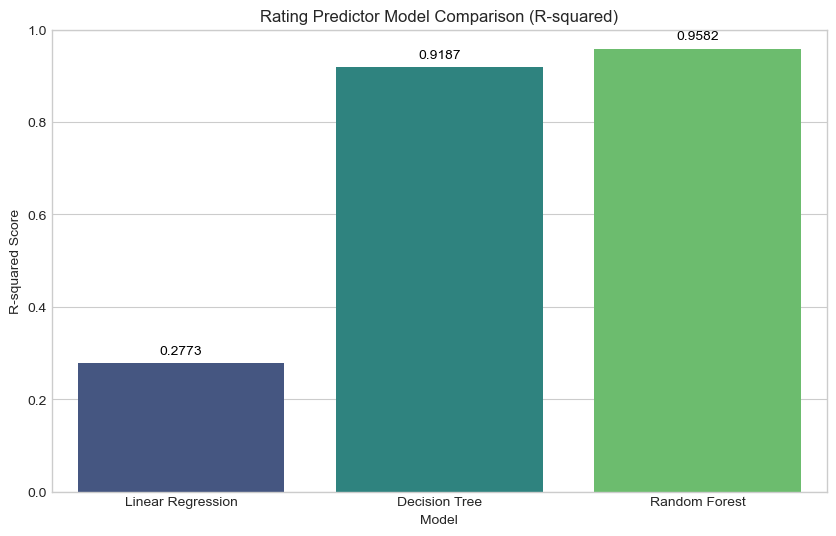

In [2]:
# Preprocessing
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
df['Has Table booking_bin'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery_bin'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
df['Cuisine Count'] = df['Cuisines'].apply(lambda x: len([c.strip() for c in x.split(',')]))

# Features & Target
features_reg = ['Average Cost for two', 'Has Table booking_bin', 'Has Online delivery_bin', 'Price range', 'Votes', 'Cuisine Count', 'Latitude', 'Longitude']
X_reg = df[features_reg]
y_reg = df['Aggregate rating']

# Train-Test Split (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, preds)
    reg_results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R-squared': r2})

results_df = pd.DataFrame(reg_results)
print(results_df)

# Plot model comparison
plt.figure()
sns.barplot(x='Model', y='R-squared', data=results_df, palette='viridis')
plt.title('Rating Predictor Model Comparison (R-squared)')
plt.ylabel('R-squared Score')
plt.ylim(0, 1.0)
for index, row in results_df.iterrows():
    plt.text(index, row['R-squared'] + 0.02, f"{row['R-squared']:.4f}", color='black', ha="center")
plt.show()

## 3. Level 1 — Task 2: Restaurant Recommendation System
Create a recommendation system using content-based filtering on cuisines, city, and locality features.


In [3]:
# Build content representation
df['Content Text'] = df['Cuisines'] + " " + df['City'] + " " + df['Locality']
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Content Text'])

# Recommendation function using cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

def recommend_restaurants(restaurant_name, top_n=5):
    # Find restaurant index
    matches = df[df['Restaurant Name'].str.lower() == restaurant_name.lower()]
    if matches.empty:
        return f"Restaurant '{restaurant_name}' not found."
    idx = matches.index[0]
    
    # Compute similarity scores
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    # Get top similar indices
    similar_indices = sim_scores.argsort()[-top_n-1:-1][::-1]
    
    recommendations = df.iloc[similar_indices][['Restaurant Name', 'Cuisines', 'City', 'Aggregate rating']]
    recommendations['Similarity'] = sim_scores[similar_indices]
    return recommendations

# Try a sample restaurant recommendation
print("Recommendations for 'Le Petit Souffle':")
print(recommend_restaurants('Le Petit Souffle'))

Recommendations for 'Le Petit Souffle':
           Restaurant Name          Cuisines         City  Aggregate rating  \
1         Izakaya Kikufuji          Japanese  Makati City               4.5   
2090            Cake Point  Bakery, Desserts      Gurgaon               2.8   
2096  Special O-cake-sions  Bakery, Desserts      Gurgaon               0.0   
2093          AK Your Food      North Indian      Gurgaon               0.0   
2095   Shri Ram Bhojnalaya      North Indian      Gurgaon               0.0   

      Similarity  
1       0.625251  
2090    0.322185  
2096    0.322185  
2093    0.311505  
2095    0.311505  


## 4. Level 2 — Task 1: Cuisine Classification
Train machine learning classifiers (Logistic Regression, Random Forest, SVM) to predict the primary cuisine of a restaurant.


In [4]:
# Extract primary cuisine
df['Primary Cuisine'] = df['Cuisines'].apply(lambda x: x.split(',')[0].strip())
top_15_cuisines = df['Primary Cuisine'].value_counts().head(15).index.tolist()

# Filter to top 15 cuisines
df_class = df[df['Primary Cuisine'].isin(top_15_cuisines)].copy()
X_class = df_class[features_reg]
y_class = df_class['Primary Cuisine']

le = LabelEncoder()
y_class_enc = le.fit_transform(y_class)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_class, y_class_enc, test_size=0.2, random_state=42)

class_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (Linear)': LinearSVC(random_state=42)
}

cls_results = {}
for name, model in class_models.items():
    model.fit(X_train_cls, y_train_cls)
    preds = model.predict(X_test_cls)
    acc = accuracy_score(y_test_cls, preds)
    cls_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Show detailed report for the best model (Random Forest)
best_model = class_models['Random Forest']
best_preds = best_model.predict(X_test_cls)
print("\nRandom Forest Classifier Report:")
print(classification_report(y_test_cls, best_preds, target_names=le.classes_))

Logistic Regression Accuracy: 0.3670


Random Forest Accuracy: 0.4206


SVM (Linear) Accuracy: 0.3850

Random Forest Classifier Report:
              precision    recall  f1-score   support

    American       0.78      0.62      0.70        64
      Bakery       0.23      0.17      0.20       129
        Cafe       0.42      0.43      0.43       115
     Chinese       0.26      0.16      0.20       172
 Continental       0.31      0.13      0.18        39
    Desserts       0.08      0.03      0.04        32
   Fast Food       0.25      0.15      0.19       144
   Ice Cream       0.28      0.12      0.17        42
     Italian       0.31      0.20      0.24        46
      Mithai       0.36      0.48      0.41        48
     Mughlai       0.17      0.07      0.10        44
North Indian       0.49      0.75      0.59       586
       Pizza       0.54      0.27      0.36        55
South Indian       0.06      0.02      0.03        47
 Street Food       0.29      0.31      0.30        42

    accuracy                           0.42      1605
   macro avg    

## 5. Level 2 — Task 2: Geographic Analysis
Plot restaurant locations and perform spatial clustering using K-Means to identify popular dining hubs.


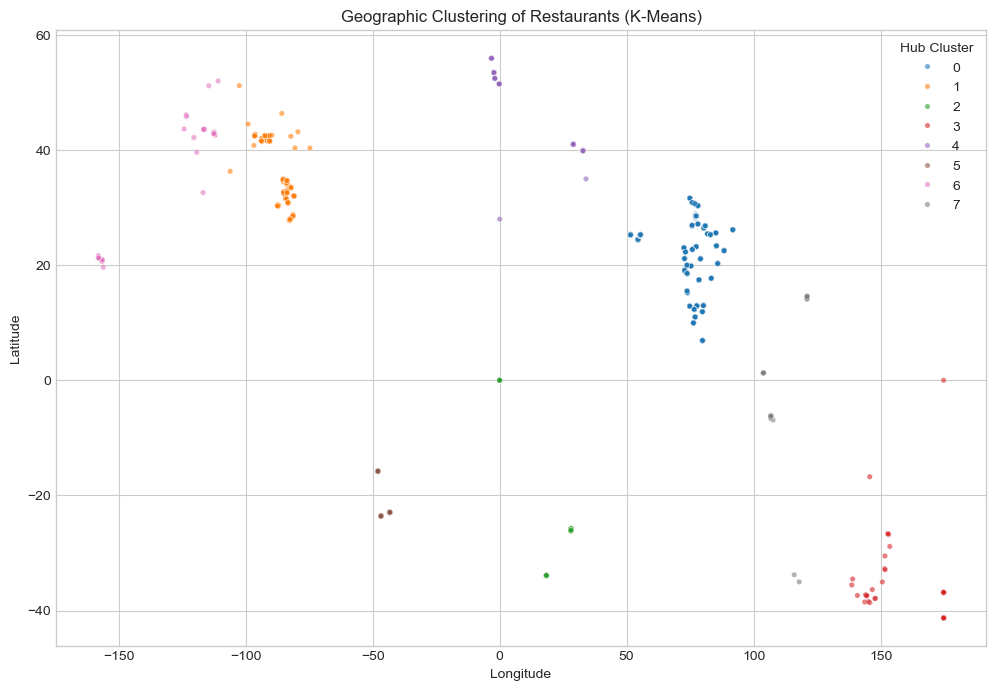

In [5]:
# K-Means clustering on coordinates
coords = df[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(coords)

# Plot restaurant clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Longitude', y='Latitude', hue='Cluster', data=df, palette='tab10', s=15, alpha=0.6)
plt.title('Geographic Clustering of Restaurants (K-Means)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Hub Cluster')
plt.show()

## 6. Level 3 — Task 1: Sentiment Analysis on Text Reviews
Since actual reviews text is missing, we create a synthetic reviews column mapped directly to the rating text categories (Excellent, Good, Average, Poor) and train a TF-IDF sentiment classifier.


In [6]:
# Sentiment mapping
sentiment_mapping = {
    'Excellent': 'positive', 'Very Good': 'positive', 'Good': 'positive',
    'Average': 'neutral', 'Poor': 'negative', 'Not rated': 'neutral'
}
df['Sentiment_Label'] = df['Rating text'].map(sentiment_mapping)

# Templates for synthetic reviews
templates = {
    'Excellent': ["Absolutely amazing! The food was delicious and service was outstanding.", "Best restaurant in town! Loved the atmosphere and prompt service."],
    'Very Good': ["Very good quality food and friendly staff.", "Great dining experience. Nice ambiance and tasty dishes."],
    'Good': ["Good food, decent price, and friendly waiters.", "Enjoyed the meal. The atmosphere was pleasant."],
    'Average': ["Average food. Nothing special or outstanding.", "Ambiance was okay, but the service was slow."],
    'Poor': ["Terrible service and cold food. Very disappointed.", "Bad taste, dirty tables, and rude staff."],
    'Not rated': ["Average experience, nothing notable to say.", "Just a normal restaurant, ok food."]
}

np.random.seed(42)
synthetic_reviews = [np.random.choice(templates[text]) for text in df['Rating text']]
df['Synthetic Review'] = synthetic_reviews

# TF-IDF + Logistic Regression Sentiment Classifier
X_text = df['Synthetic Review']
y_sent = df['Sentiment_Label']

tfidf_sent = TfidfVectorizer()
X_text_tfidf = tfidf_sent.fit_transform(X_text)

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(X_text_tfidf, y_sent, test_size=0.2, random_state=42)

sent_model = LogisticRegression(random_state=42)
sent_model.fit(X_train_txt, y_train_txt)
sent_preds = sent_model.predict(X_test_txt)

print(f"Sentiment Model Accuracy: {accuracy_score(y_test_txt, sent_preds):.4f}")
print(classification_report(y_test_txt, sent_preds))

# Test classifier
test_review = ["The burger was delicious and the staff was extremely friendly!"]
test_tfidf = tfidf_sent.transform(test_review)
print(f"Test Review: '{test_review[0]}' -> Sentiment: {sent_model.predict(test_tfidf)[0]}")

Sentiment Model Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        30
     neutral       1.00      1.00      1.00      1177
    positive       1.00      1.00      1.00       704

    accuracy                           1.00      1911
   macro avg       1.00      1.00      1.00      1911
weighted avg       1.00      1.00      1.00      1911

Test Review: 'The burger was delicious and the staff was extremely friendly!' -> Sentiment: positive


## 7. Level 3 — Task 2: Feature Engineering & Model Improvement
Analyze the impact of engineered features (Cuisine Count, Name Length, Address Length, and Cost per Person) on predictive regression performance.


R-squared without engineered features: 0.95762
R-squared with engineered features   : 0.95956
Improvement                          : 0.00194


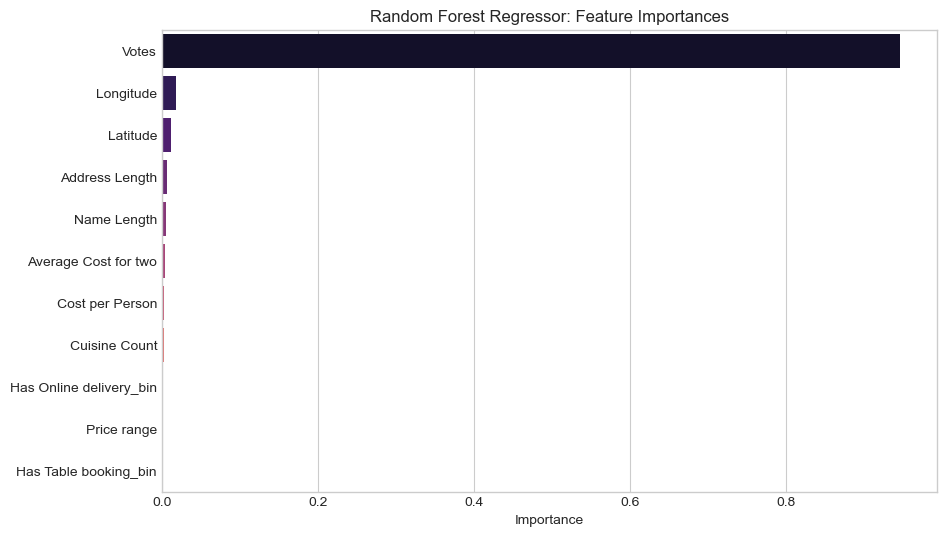

In [7]:
# Add engineered features
df['Name Length'] = df['Restaurant Name'].apply(lambda x: len(str(x)))
df['Address Length'] = df['Address'].apply(lambda x: len(str(x)))
df['Cost per Person'] = df['Average Cost for two'] / 2.

# Compare Random Forest performance with vs. without engineered features
features_without = ['Average Cost for two', 'Has Table booking_bin', 'Has Online delivery_bin', 'Price range', 'Votes', 'Latitude', 'Longitude']
features_with = features_without + ['Cuisine Count', 'Name Length', 'Address Length', 'Cost per Person']

# Train-Test Splits
X_train_w_o, X_test_w_o, y_train_w_o, y_test_w_o = train_test_split(df[features_without], y_reg, test_size=0.2, random_state=42)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(df[features_with], y_reg, test_size=0.2, random_state=42)

# Models
rf_wo = RandomForestRegressor(n_estimators=100, random_state=42)
rf_wo.fit(X_train_w_o, y_train_w_o)
preds_wo = rf_wo.predict(X_test_w_o)
r2_wo = r2_score(y_test_w_o, preds_wo)

rf_w = RandomForestRegressor(n_estimators=100, random_state=42)
rf_w.fit(X_train_w, y_train_w)
preds_w = rf_w.predict(X_test_w)
r2_w = r2_score(y_test_w, preds_w)

print(f"R-squared without engineered features: {r2_wo:.5f}")
print(f"R-squared with engineered features   : {r2_w:.5f}")
print(f"Improvement                          : {r2_w - r2_wo:.5f}")

# Plot feature importances
importances = rf_w.feature_importances_
indices = np.argsort(importances)[::-1]
features_with_sorted = [features_with[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features_with_sorted, palette='magma')
plt.title('Random Forest Regressor: Feature Importances')
plt.xlabel('Importance')
plt.show()